# Feature Relationships and Multicollinearity Analysis

## Introduction

In the previous exploratory data analysis, we already started to see that some variables are not completely independent.

In particular:

- Some features appear to be strongly related or even derived from others (for example, TotalCharges in relation to tenure and MonthlyCharges)
- Certain groups of variables describe very similar aspects of customer behavior, such as additional services linked to internet subscriptions (e.g., OnlineSecurity, StreamingTV, TechSupport)
- This suggests that some features may be carrying overlapping information

At this point, it becomes important to take a step back and look at these relationships more systematically.

If multiple variables contain similar information, this can:
- introduce redundancy
- make models harder to interpret
- and in some cases negatively affect performance (especially for linear models)

In this notebook, we focus on analyzing relationships between variables more formally. The goal is to identify:

- Strong dependencies between numerical features  
- Associations between categorical variables  
- Potential multicollinearity issues  

These findings will help guide feature selection and transformations in the next steps of the project.

## Table of Contents

1. [Numerical Feature Relationships](#numerical-feature-relationships)
2. [Categorical Feature Associations](#categorical-feature-associations)
3. [Multicollinearity Analysis](#multicollinearity-and-feature-redundancy)
4. [Conclusion](#conclusion)

## Numerical Feature Relationships

The dataset contains a small number of numerical features, mainly related to customer tenure and billing:

- `tenure`
- `MonthlyCharges`
- `TotalCharges`

From the previous analysis, we already saw indications that these variables are not independent. In particular, `TotalCharges` is likely influenced by both `tenure` and `MonthlyCharges`, since it represents the accumulated amount a customer has paid over time.

Before moving further, it is useful to examine these relationships more explicitly.

If some of these variables carry very similar information, they may introduce redundancy and potentially affect model behavior, especially for models that assume independent features.

In this section, we use correlation analysis to better understand the relationships between numerical variables and identify possible dependencies.

In [1]:
import polars as pl

df_ram_start = pl.read_csv("data/processed/03_eda_train_df_end.csv")
df_ram_start.head()

SeniorCitizenRelevel,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
str,str,str,i64,str,str,str,str,str,str,str,str,str,str,f64,f64,str
"""No""","""No""","""No""",2,"""DSL""","""Yes""","""Yes""","""No""","""No""","""No""","""No""","""Month-to-month""","""Yes""","""Mailed check""",53.85,108.15,"""Yes"""
"""No""","""No""","""No""",2,"""Fiber optic""","""No""","""No""","""No""","""No""","""No""","""No""","""Month-to-month""","""Yes""","""Electronic check""",70.7,151.65,"""Yes"""
"""No""","""No""","""No""",8,"""Fiber optic""","""No""","""No""","""Yes""","""No""","""Yes""","""Yes""","""Month-to-month""","""Yes""","""Electronic check""",99.65,820.5,"""Yes"""
"""No""","""Yes""","""No""",28,"""Fiber optic""","""No""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""Month-to-month""","""Yes""","""Electronic check""",104.8,3046.05,"""Yes"""
"""No""","""No""","""No""",49,"""Fiber optic""","""No""","""Yes""","""Yes""","""No""","""Yes""","""Yes""","""Month-to-month""","""Yes""","""Bank transfer (automatic)""",103.7,5036.3,"""Yes"""


In [2]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
corr_df = df_ram_start.select(num_cols).corr()
corr_df

tenure,MonthlyCharges,TotalCharges
f64,f64,f64
1.0,0.248015,0.826128
0.248015,1.0,0.650623
0.826128,0.650623,1.0


From the correlation table we can see what we exactly knew already, that the TotalCharges are heavily influenced by the tenure.

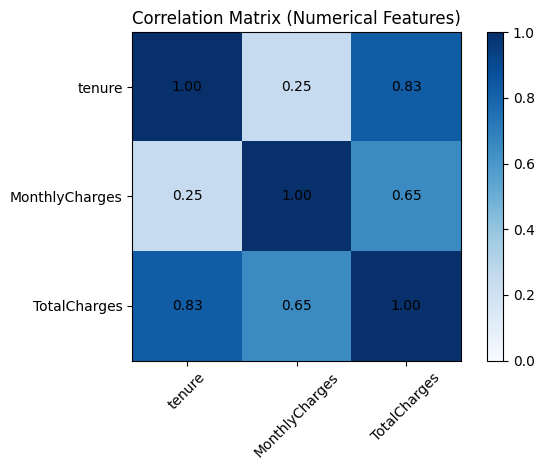

In [3]:
import matplotlib.pyplot as plt

# Compute correlation
corr_matrix = abs(corr_df.to_numpy())

fig, ax = plt.subplots()

cax = ax.imshow(corr_matrix, cmap="Blues", vmin=0, vmax=1)

# Colorbar
fig.colorbar(cax)

# Ticks
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))

ax.set_xticklabels(num_cols, rotation=45)
ax.set_yticklabels(num_cols)

# Annotate values
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr_matrix[i, j]:.2f}", ha="center", va="center")

ax.set_title("Correlation Matrix (Numerical Features)")

plt.tight_layout()
plt.show()

### Summary of Numerical Feature Relationships

The correlation analysis confirms what we already observed during the exploratory phase.

`TotalCharges` shows a strong relationship with `tenure` (0.83) and a moderate relationship with `MonthlyCharges` (0.65). This is expected, as `TotalCharges` represents the cumulative amount a customer has paid over time. In practice, it is largely driven by how long the customer has stayed (`tenure`) and how much they are charged on a monthly basis.

At the same time, tenure and `MonthlyCharges` are only weakly correlated (0.25), suggesting that they capture different aspects of customer behavior.

This creates a situation where `TotalCharges` does not introduce much new information, but rather combines information already present in the other two variables.

In a typical feature selection workflow, we might compare each variable directly against the target (`churn`) and select the one with the strongest predictive power. This could be done, for example, by:

- comparing AUC scores using single-variable models  
- fitting simple logistic regression models and evaluating coefficients and significance  
- using univariate feature importance measures  

However, in this case, the dependency structure between variables is already clear from the data itself.

Given the strong correlation between `TotalCharges` and `tenure`, and its additional dependency on `MonthlyCharges`, keeping `TotalCharges` would introduce redundancy without adding meaningful new information.

For this reason, `TotalCharges` will be excluded from further analysis.

The focus will remain on `tenure` and `MonthlyCharges`, which provide more direct and less overlapping signals. `MonthlyCharges` may still require transformation in the feature engineering stage to better capture its relationship with `churn`.

In [4]:
df_ram = df_ram_start.drop(["TotalCharges"])
df_ram.columns

['SeniorCitizenRelevel',
 'Partner',
 'Dependents',
 'tenure',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'Churn']

In [5]:
df_ram.write_csv("./data/processed/04_ram_train_df_cm.csv")

## Categorical Feature Associations

Most variables in the dataset are categorical and often represent different aspects of customer behavior, such as subscribed services or contract details. From the earlier analysis, it was already apparent that some of these features are closely related, particularly within groups like internet-related services.

To better understand these relationships, we need a way to quantify how strongly categorical variables are associated with each other.

To quantify these relationships more systematically, we use Cramér’s V. It provides a measure of association between two categorical variables, with values ranging from 0 (no relationship) to 1 (strong relationship).

This allows us to move beyond simple observation and systematically identify groups of variables that may carry overlapping or redundant information.

In [6]:
import numpy as np
import polars as pl
from scipy.stats import chi2_contingency

def cramers_v(df: pl.DataFrame, col1: str, col2: str) -> float:
    if col1 == col2:
        return 1.0
    contingency = (
        df.group_by([col1, col2])
        .len()
        .pivot(
            values="len",
            index=col1,
            on=col2
        )
        .fill_null(0)
        .sort(col1)
    )

    matrix = contingency.drop(col1).to_numpy()

    chi2 = chi2_contingency(matrix)[0]
    n = matrix.sum()
    r, k = matrix.shape

    return float(np.sqrt(chi2 / (n * min(r - 1, k - 1))))

In [7]:
cat_cols = ['SeniorCitizenRelevel',
            'Partner',
            'Dependents',
            'InternetService',
            'OnlineSecurity',
            'OnlineBackup',
            'DeviceProtection',
            'TechSupport',
            'StreamingTV',
            'StreamingMovies',
            'Contract',
            'PaperlessBilling',
            'PaymentMethod']

cramers_matrix = []

for col1 in cat_cols:
    row = []
    for col2 in cat_cols:
        row.append(cramers_v(df_ram, col1, col2))
    cramers_matrix.append(row)

cramers_matrix = np.array(cramers_matrix)

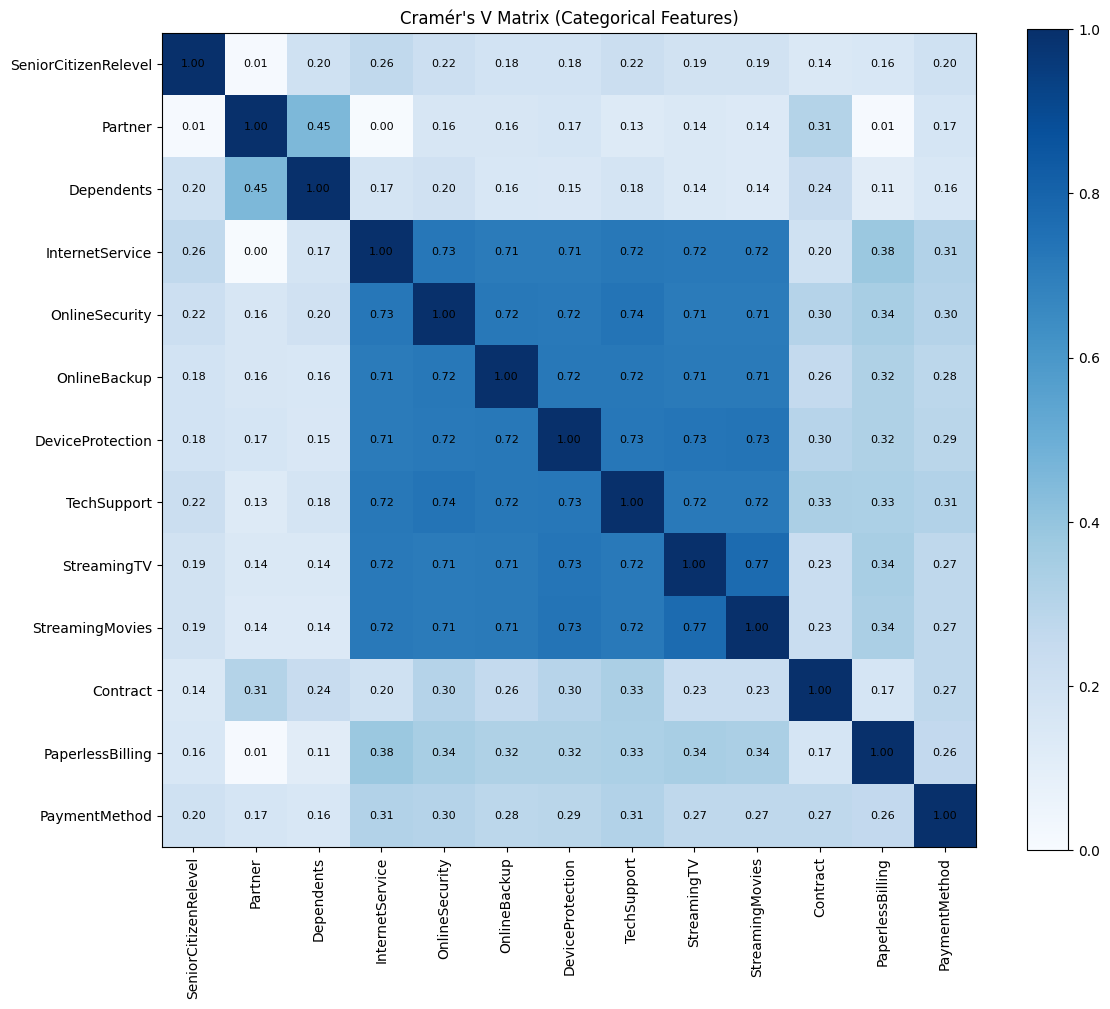

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

cax = ax.imshow(cramers_matrix, cmap="Blues", vmin=0, vmax=1)
fig.colorbar(cax)

ax.set_xticks(range(len(cat_cols)))
ax.set_yticks(range(len(cat_cols)))

ax.set_xticklabels(cat_cols, rotation=90)
ax.set_yticklabels(cat_cols)

# Add values inside squares
for i in range(len(cat_cols)):
    for j in range(len(cat_cols)):
        value = cramers_matrix[i, j]
        ax.text(
            j, i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

ax.set_title("Cramér's V Matrix (Categorical Features)")

plt.tight_layout()
plt.show()

### Summary of Categorical Feature Associations

The Cramér’s V analysis confirms the relationships that were already suggested during the exploratory phase.

A clear pattern emerges among internet-related service features such as `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, and `StreamingMovies`. These variables show strong associations with each other (generally above 0.7), indicating that they describe closely related aspects of the same underlying concept — the set of services a customer subscribes to.

At the same time, `InternetService` itself is also strongly associated with these features, which is expected, as it defines the type of connection that enables these services.

This means that these variables are not independent and carry overlapping information. However, unlike in the numerical case, this does not imply that one variable can simply be removed.

Each of these features still represents a specific service, and removing them would result in a loss of potentially important detail about customer behavior.

Instead, this situation points toward the need for feature engineering. Rather than selecting a single variable, it may be more appropriate to:

- group related features into aggregated variables  
- capture the number of subscribed services  
- or transform these variables in a way that reduces redundancy while preserving information  

Other features, such as `Contract`, `PaymentMethod`, and `PaperlessBilling`, show moderate associations with some of the service-related variables, suggesting that they may interact with customer behavior in a different way and should be analyzed further in relation to churn.

Overall, the analysis highlights that while strong associations exist among several categorical variables, they reflect meaningful structure in the data rather than simple redundancy. These relationships will be addressed in the feature engineering stage.

## Multicollinearity and Feature Redundancy

Based on the previous analyses, several relationships between variables have been identified across both numerical and categorical features.

For numerical variables, `TotalCharges` was shown to be strongly dependent on `tenure` and moderately related to `MonthlyCharges`. This indicates that it largely combines information already present in other variables, making it redundant in the context of modeling.

For categorical variables, strong associations were observed within groups of related features, particularly among internet-related services. In this case, the relationships reflect shared structure rather than simple duplication, as each variable still represents a specific aspect of customer behavior.

This highlights two different types of multicollinearity:

- Direct redundancy, where one variable can be expressed through others (e.g., `TotalCharges`)  
- Structural dependency, where multiple variables describe closely related aspects of the same concept  

These cases require different handling:

- Redundant numerical features can be removed  
- Strongly related categorical features should be addressed through feature engineering rather than elimination  

It is also worth noting that multicollinearity mainly affects models that assume independence between features, such as linear and logistic regression. Tree-based models are generally less sensitive, but reducing redundancy can still improve interpretability and stability.

Overall, this analysis clarifies how different types of relationships should be handled and provides a clear direction for the feature engineering step.

## Conclusion

In this notebook, relationships between variables were analyzed to better understand dependencies and potential redundancy in the dataset.

For numerical features, TotalCharges was identified as redundant and will be excluded from further analysis.

For categorical features, strong associations were observed within groups of related variables, particularly among internet-related services. These relationships reflect underlying structure rather than duplication and will be addressed through feature engineering.

It is also worth noting that relationships between numerical and categorical variables were not explored in detail at this stage. While such analysis can provide additional insights into how numerical features vary across categories, it is less relevant for identifying redundancy between features.

Given the focus of this notebook on dependencies and multicollinearity, the analysis was limited to relationships within numerical and categorical groups. Interactions between these variable types will be considered later when refining features for modeling.

These findings establish a clear foundation for the next step, where features will be transformed and prepared for modeling.

In [9]:
# save the data at the end of the notebook as input for the next notebook
df_ram.write_csv("./data/processed/04_ram_train_df_end.csv")

In [10]:
import json

feature_config = {
    "dropped_features": ["TotalCharges"]
}

with open("./data/configs/02_ram.json", "w") as f:
    json.dump(feature_config, f)